In [16]:
!pip install git+https://github.com/huggingface/transformers.git@main


  Cloning https://github.com/huggingface/transformers.git (to revision main) to /tmp/pip-req-build-bbkp4k2h
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-bbkp4k2h
  Resolved https://github.com/huggingface/transformers.git to commit b7b9d25226d7b4e9ec2f6eac5f7839adc195fa43
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [17]:
!pip install -q datasets

Load the image captioning datsets

In [18]:
from datasets import load_dataset
datasets = load_dataset ("ybelkada/football-dataset",split="train")

In [19]:
datasets[0]["text"]

"Benzema after Real Mardid's win against PSG"

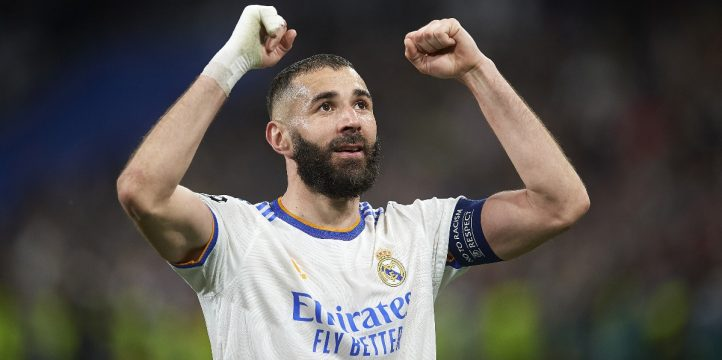

In [20]:
datasets[0]["image"]

In [21]:
from huggingface_hub import Padding
from torch.utils.data import Dataset, DataLoader

class ImageCaptioningDataset(Dataset):
  def __init__(self,dataset, processor):
    self.dataset=dataset
    self.processor=processor

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    item=self.dataset[idx]
    encoding = self.processor(images=item["image"], text=item["text"],padding="max_length", return_tensors="pt")

    #remove baatch extension
    encoding={k:v.squeeze() for k,v in encoding.items()}
    return encoding

In [22]:
from transformers import AutoProcessor, BlipForConditionalGeneration
processor = AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Now that we have loaded the processor, let's load the dataset and the dataloader

In [23]:
train_dataset = ImageCaptioningDataset(datasets,processor)
train_dataloader = DataLoader(train_dataset,shuffle=True, batch_size=2)

#**Train the model**

Let's train the model !Run the simply cell beow for  training the model

In [24]:
import torch

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

for epoch in range(50):                      # echo → epoch
    print("Epoch :", epoch)

    for idx, batch in enumerate(train_dataloader):
        input_ids = batch["input_ids"].to(device)      # no pop
        pixel_values = batch["pixel_values"].to(device)

        outputs = model(
            input_ids=input_ids,
            pixel_values=pixel_values,
            labels=input_ids
        )

        loss = outputs.loss
        print("Loss:", loss.item())

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()


Epoch : 0


We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


Loss: 13.027508735656738
Loss: 10.285558700561523
Loss: 10.17722225189209
Epoch : 1
Loss: 10.20731258392334
Loss: 10.171404838562012
Loss: 10.117384910583496
Epoch : 2
Loss: 10.097968101501465
Loss: 10.070413589477539
Loss: 10.111716270446777
Epoch : 3
Loss: 10.028507232666016
Loss: 10.078123092651367
Loss: 10.019059181213379
Epoch : 4
Loss: 9.992103576660156
Loss: 9.92552375793457
Loss: 9.280513763427734
Epoch : 5
Loss: 8.870773315429688
Loss: 8.607672691345215
Loss: 8.285765647888184
Epoch : 6
Loss: 8.087007522583008
Loss: 7.853120803833008
Loss: 7.663970947265625
Epoch : 7
Loss: 7.462684631347656
Loss: 7.309225559234619
Loss: 7.135104656219482
Epoch : 8
Loss: 6.964737892150879
Loss: 6.825258255004883
Loss: 6.686383247375488
Epoch : 9
Loss: 6.521385192871094
Loss: 6.4002275466918945
Loss: 6.244202136993408
Epoch : 10
Loss: 6.094784259796143
Loss: 5.964621067047119
Loss: 5.797600269317627
Epoch : 11
Loss: 5.659274101257324
Loss: 5.528046131134033
Loss: 5.362227916717529
Epoch : 12
Los

Load



Let's check the result on our train dataset

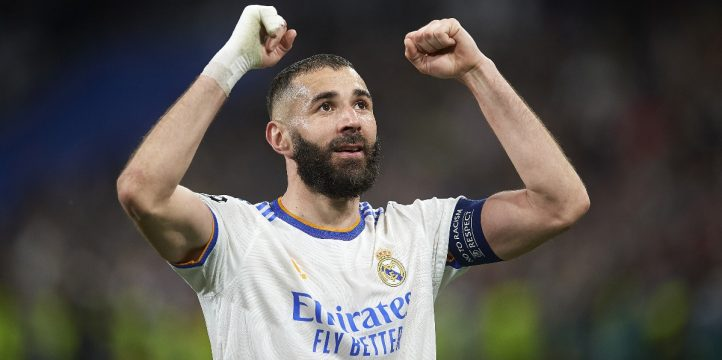

In [25]:
example = datasets[0]
image= example["image"]
image

#prepare the image for the model

In [29]:
inputs = processor(images = image, return_tensors="pt").to(device)
pixel_values = inputs.pixel_values

generated_ids = model.generate(pixel_values=pixel_values, max_length =50)
generated_caption = processor.batch_decode(generated_ids, skip_special_tokens = True)[0]
print(generated_caption)

benzema after real mardid ' s win against psg
